# Iniezione GWB a tre ampiezze (-15.0, -14.5, -15.5)

Estratto da `Likelihood.ipynb`, celle 73–102 (copiate senza modifiche, output inclusi).

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`: import, caricamento della pulsar J1640+2224 (DR2low), modello, likelihood, prior, likelihood jittata.

In [40]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

In [41]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [43]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [44]:
logL = ds.PulsarLikelihood(model).logL

In [46]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [86]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  1.41657955, -15.20565157,   3.04626604, -12.5891013 ,
         5.8842367 , -19.77807228])

In [49]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catene da altre analisi

Necessarie per i confronti incrociati di questo notebook. Copia delle celle 13, 70 di `Likelihood.ipynb`: le catene vengono lette da disco (nessun sampling).

In [58]:
# read the output chain that has shape (n_samples, n_parameters)
chain = np.loadtxt('./test/chain_1.txt')[:, :-4]
chain = chain[len(chain) // 4:] # remove first 25% from the chain
chain.shape

(75001, 6)

In [8]:
chain_sim2 = np.loadtxt('./test_sim2/chain_1.txt')[:, :-4]
chain_sim2 = chain_sim2[len(chain_sim2)//4:]
chain_sim2.shape   # atteso (~75000, 6)

(75001, 6)

## Analisi (celle 73–102 dell'originale)

In [61]:
sim_gwb_psr = ds.pulsar.Pulsar.read_feather('sim_data_noiseGWB/J1640+2224')
print('nome     :', sim_gwb_psr.name)
print('N_TOA    :', len(sim_gwb_psr.toas))
print('shape M  :', sim_gwb_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [62]:
# analizzo i dati con GWB usando lo stesso modello a 6 par dei dati reali
# (fingo di non sapere che c'e il GWB, per vedere se il red noise lo "assorbe")
model_sim_gwb = [sim_gwb_psr.residuals]
model_sim_gwb += [ds.makegp_timing(sim_gwb_psr, svd=True)]
model_sim_gwb += [ds.makenoise_measurement(sim_gwb_psr, sim_gwb_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_gwb.append(ds.makegp_fourier(sim_gwb_psr, ds.powerlaw, sim_gwb_psr.noisedict[sim_gwb_psr.name + '_red_components'],
                                       T=ds.getspan(sim_gwb_psr), name='red_noise'))
model_sim_gwb.append(ds.makegp_fourier(sim_gwb_psr, ds.powerlaw, sim_gwb_psr.noisedict[sim_gwb_psr.name + '_dm_components'],
                                       T=ds.getspan(sim_gwb_psr), name='dm_gp',
                                       fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_gwb.append(ds.makegp_fourier(sim_gwb_psr, ds.powerlaw, sim_gwb_psr.noisedict[sim_gwb_psr.name + '_chrom_components'],
                                       T=ds.getspan(sim_gwb_psr), name='sv_gp',
                                       fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim_gwb = ds.PulsarLikelihood(model_sim_gwb).logL
logL_sim_gwb.params    # atteso: 6 parametri, senza gwb

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [63]:
def params_dict_from_array_sim_gwb(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_gwb.params, x))

priors_sim_gwb = build_priors(logL_sim_gwb.params, my_priordict)

def log_prior_sim_gwb(x):
    params = params_dict_from_array_sim_gwb(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_gwb:
            logp += priors_sim_gwb[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_gwb():
    return np.array([priors_sim_gwb[name].rvs() for name in logL_sim_gwb.params])

x0_sim_gwb = prior_draw_sim_gwb()

In [64]:
@jax.jit
def _jit_logL_sim_gwb(params_array):
    return logL_sim_gwb(dict(zip(logL_sim_gwb.params, params_array)))

def log_likelihood_sim_gwb(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_gwb(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_gwb(x0_sim_gwb))

logL iniziale = 68130.22837383955


In [65]:
sampler_sim_gwb = ptmcmc(
    ndim=len(logL_sim_gwb.params),
    logl=log_likelihood_sim_gwb,
    logp=log_prior_sim_gwb,
    cov=np.eye(len(logL_sim_gwb.params)) * 0.001,
    outDir='./test_sim_gwb/',
    resume=True
)

In [94]:
print("Starting sampling (dati simulati CON GWB iniettato, analizzati SENZA modello GWB)...")
sampler_sim_gwb.sample(x0_sim_gwb, Niter=1000000, thin=10)

Starting sampling (dati simulati CON GWB iniettato, analizzati SENZA modello GWB)...
Finished 1.00 percent (1.00 percent of new work) in 13.016156 s Acceptance rate = 0.2066Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 3110.558124 s Acceptance rate = 0.337581
Run Complete


In [66]:
chain_sim_gwb = np.loadtxt('./test_sim_gwb/chain_1.txt')[:, :-4]
chain_sim_gwb = chain_sim_gwb[len(chain_sim_gwb)//4:]
chain_sim_gwb.shape   # atteso (~75000, 6)

(75001, 6)

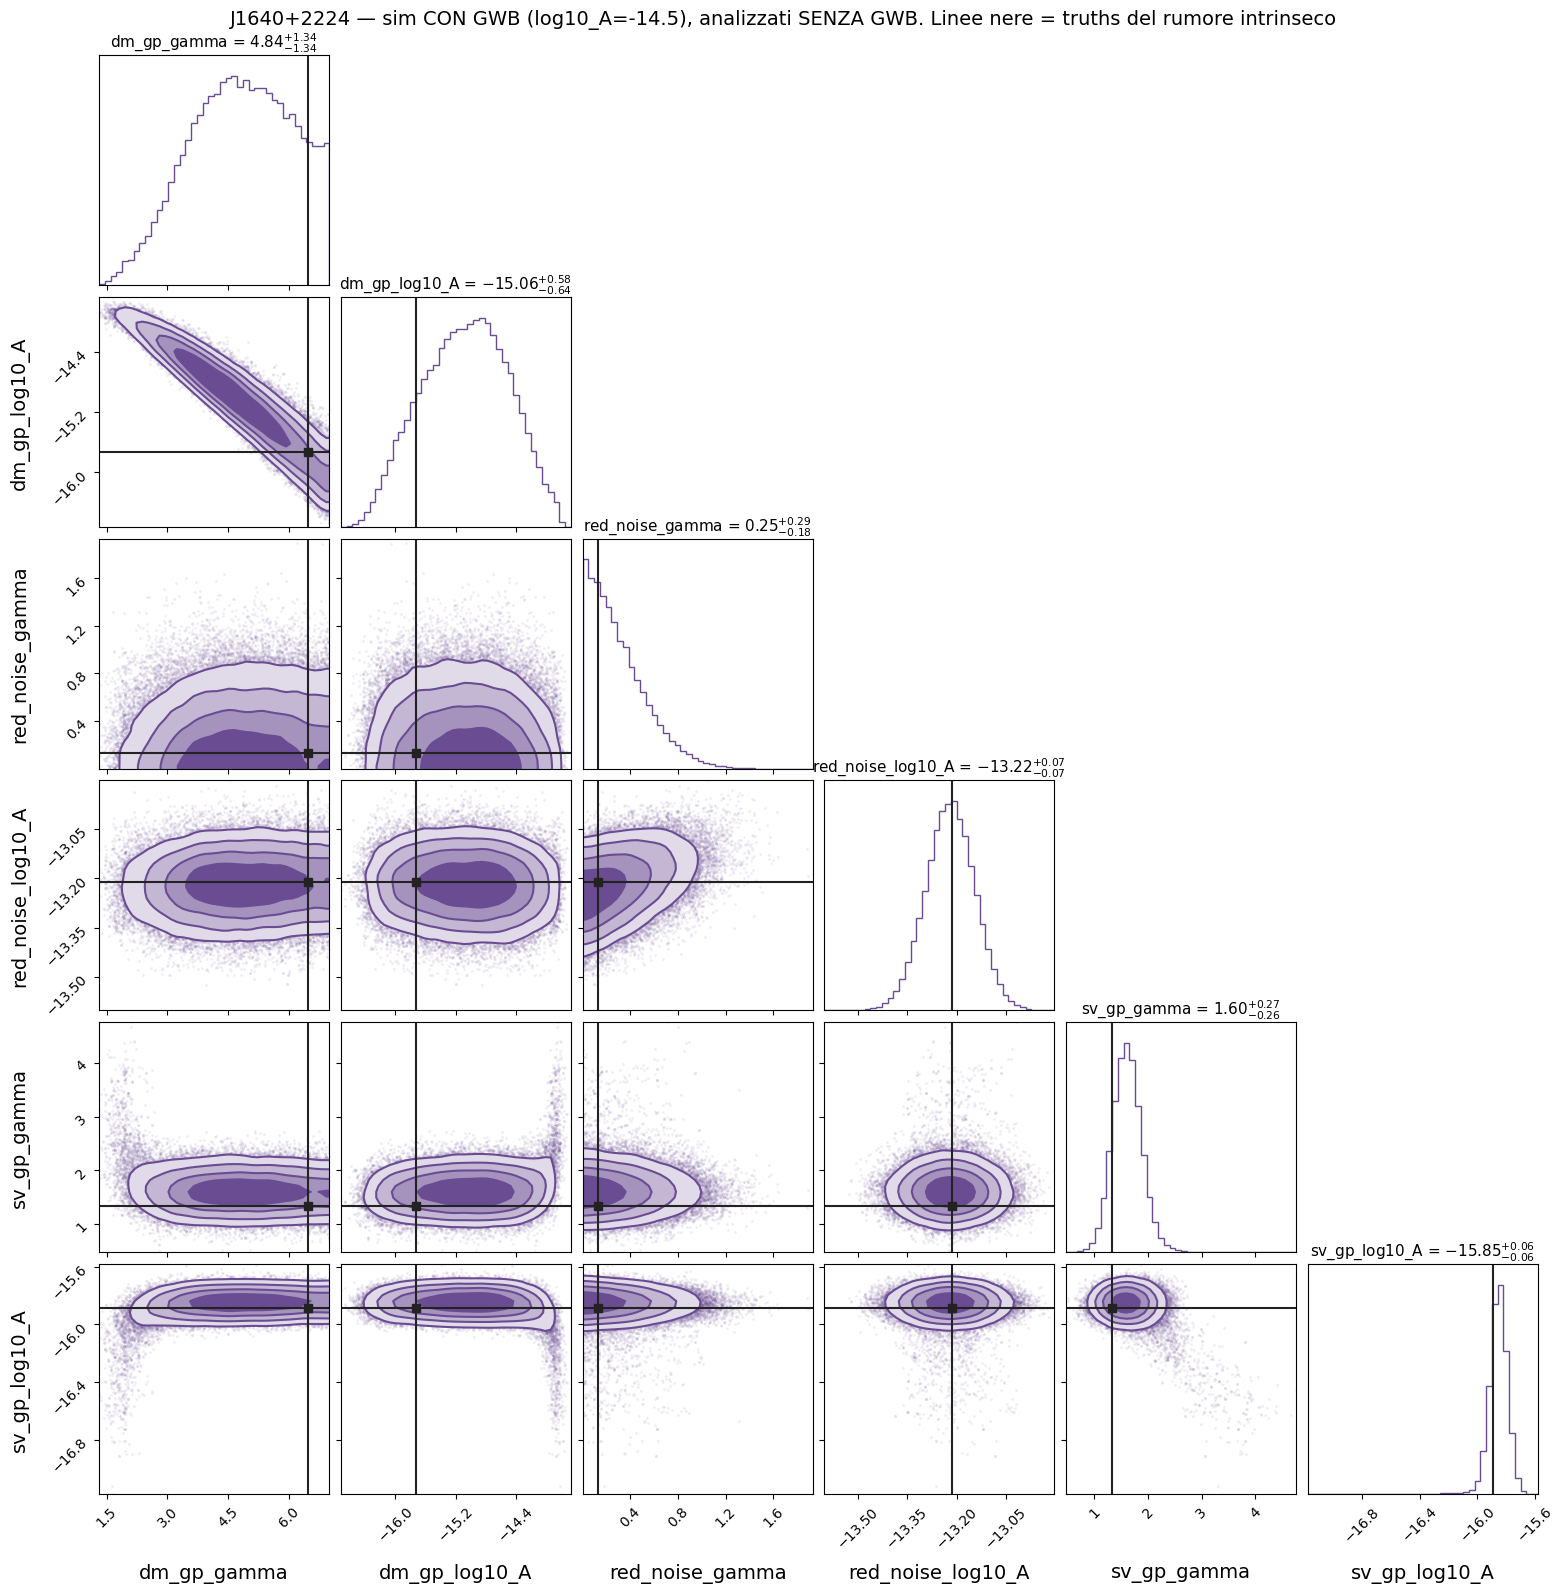

In [67]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_gwb.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb.params]

fig = corner.corner(
    chain_sim_gwb[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#6A4C93',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim CON GWB (log10_A=-14.5), analizzati SENZA GWB. Linee nere = truths del rumore intrinseco',
             fontsize=14, y=1.00)
fig.savefig('corner_sim_gwb.png', dpi=150, bbox_inches='tight')

In [68]:
sim_gwb2_psr = ds.pulsar.Pulsar.read_feather('sim_data_noiseGWB_A145/J1640+2224')
print('nome     :', sim_gwb2_psr.name)
print('N_TOA    :', len(sim_gwb2_psr.toas))
print('shape M  :', sim_gwb2_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [69]:
# analizzo i dati con GWB (A=-14.5) usando lo stesso modello a 6 par dei dati reali
model_sim_gwb2 = [sim_gwb2_psr.residuals]
model_sim_gwb2 += [ds.makegp_timing(sim_gwb2_psr, svd=True)]
model_sim_gwb2 += [ds.makenoise_measurement(sim_gwb2_psr, sim_gwb2_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_gwb2.append(ds.makegp_fourier(sim_gwb2_psr, ds.powerlaw, sim_gwb2_psr.noisedict[sim_gwb2_psr.name + '_red_components'],
                                        T=ds.getspan(sim_gwb2_psr), name='red_noise'))
model_sim_gwb2.append(ds.makegp_fourier(sim_gwb2_psr, ds.powerlaw, sim_gwb2_psr.noisedict[sim_gwb2_psr.name + '_dm_components'],
                                        T=ds.getspan(sim_gwb2_psr), name='dm_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_gwb2.append(ds.makegp_fourier(sim_gwb2_psr, ds.powerlaw, sim_gwb2_psr.noisedict[sim_gwb2_psr.name + '_chrom_components'],
                                        T=ds.getspan(sim_gwb2_psr), name='sv_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim_gwb2 = ds.PulsarLikelihood(model_sim_gwb2).logL
logL_sim_gwb2.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [70]:
def params_dict_from_array_sim_gwb2(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_gwb2.params, x))

priors_sim_gwb2 = build_priors(logL_sim_gwb2.params, my_priordict)

def log_prior_sim_gwb2(x):
    params = params_dict_from_array_sim_gwb2(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_gwb2:
            logp += priors_sim_gwb2[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_gwb2():
    return np.array([priors_sim_gwb2[name].rvs() for name in logL_sim_gwb2.params])

x0_sim_gwb2 = prior_draw_sim_gwb2()

In [71]:
@jax.jit
def _jit_logL_sim_gwb2(params_array):
    return logL_sim_gwb2(dict(zip(logL_sim_gwb2.params, params_array)))

def log_likelihood_sim_gwb2(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_gwb2(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_gwb2(x0_sim_gwb2))

logL iniziale = 67584.12575646015


In [72]:
sampler_sim_gwb2 = ptmcmc(
    ndim=len(logL_sim_gwb2.params),
    logl=log_likelihood_sim_gwb2,
    logp=log_prior_sim_gwb2,
    cov=np.eye(len(logL_sim_gwb2.params)) * 0.001,
    outDir='./test_sim_gwb_A145/',
    resume=True
)

In [102]:
print("Starting sampling (dati simulati CON GWB log10_A=-14.5, analizzati SENZA GWB)...")
sampler_sim_gwb2.sample(x0_sim_gwb2, Niter=1000000, thin=10)

Starting sampling (dati simulati CON GWB log10_A=-14.5, analizzati SENZA GWB)...
Finished 1.00 percent (1.00 percent of new work) in 13.576804 s Acceptance rate = 0.21Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 1741.739730 s Acceptance rate = 0.28293
Run Complete


In [73]:
chain_sim_gwb2 = np.loadtxt('./test_sim_gwb_A145/chain_1.txt')[:, :-4]
chain_sim_gwb2 = chain_sim_gwb2[len(chain_sim_gwb2)//4:]
chain_sim_gwb2.shape

(75001, 6)

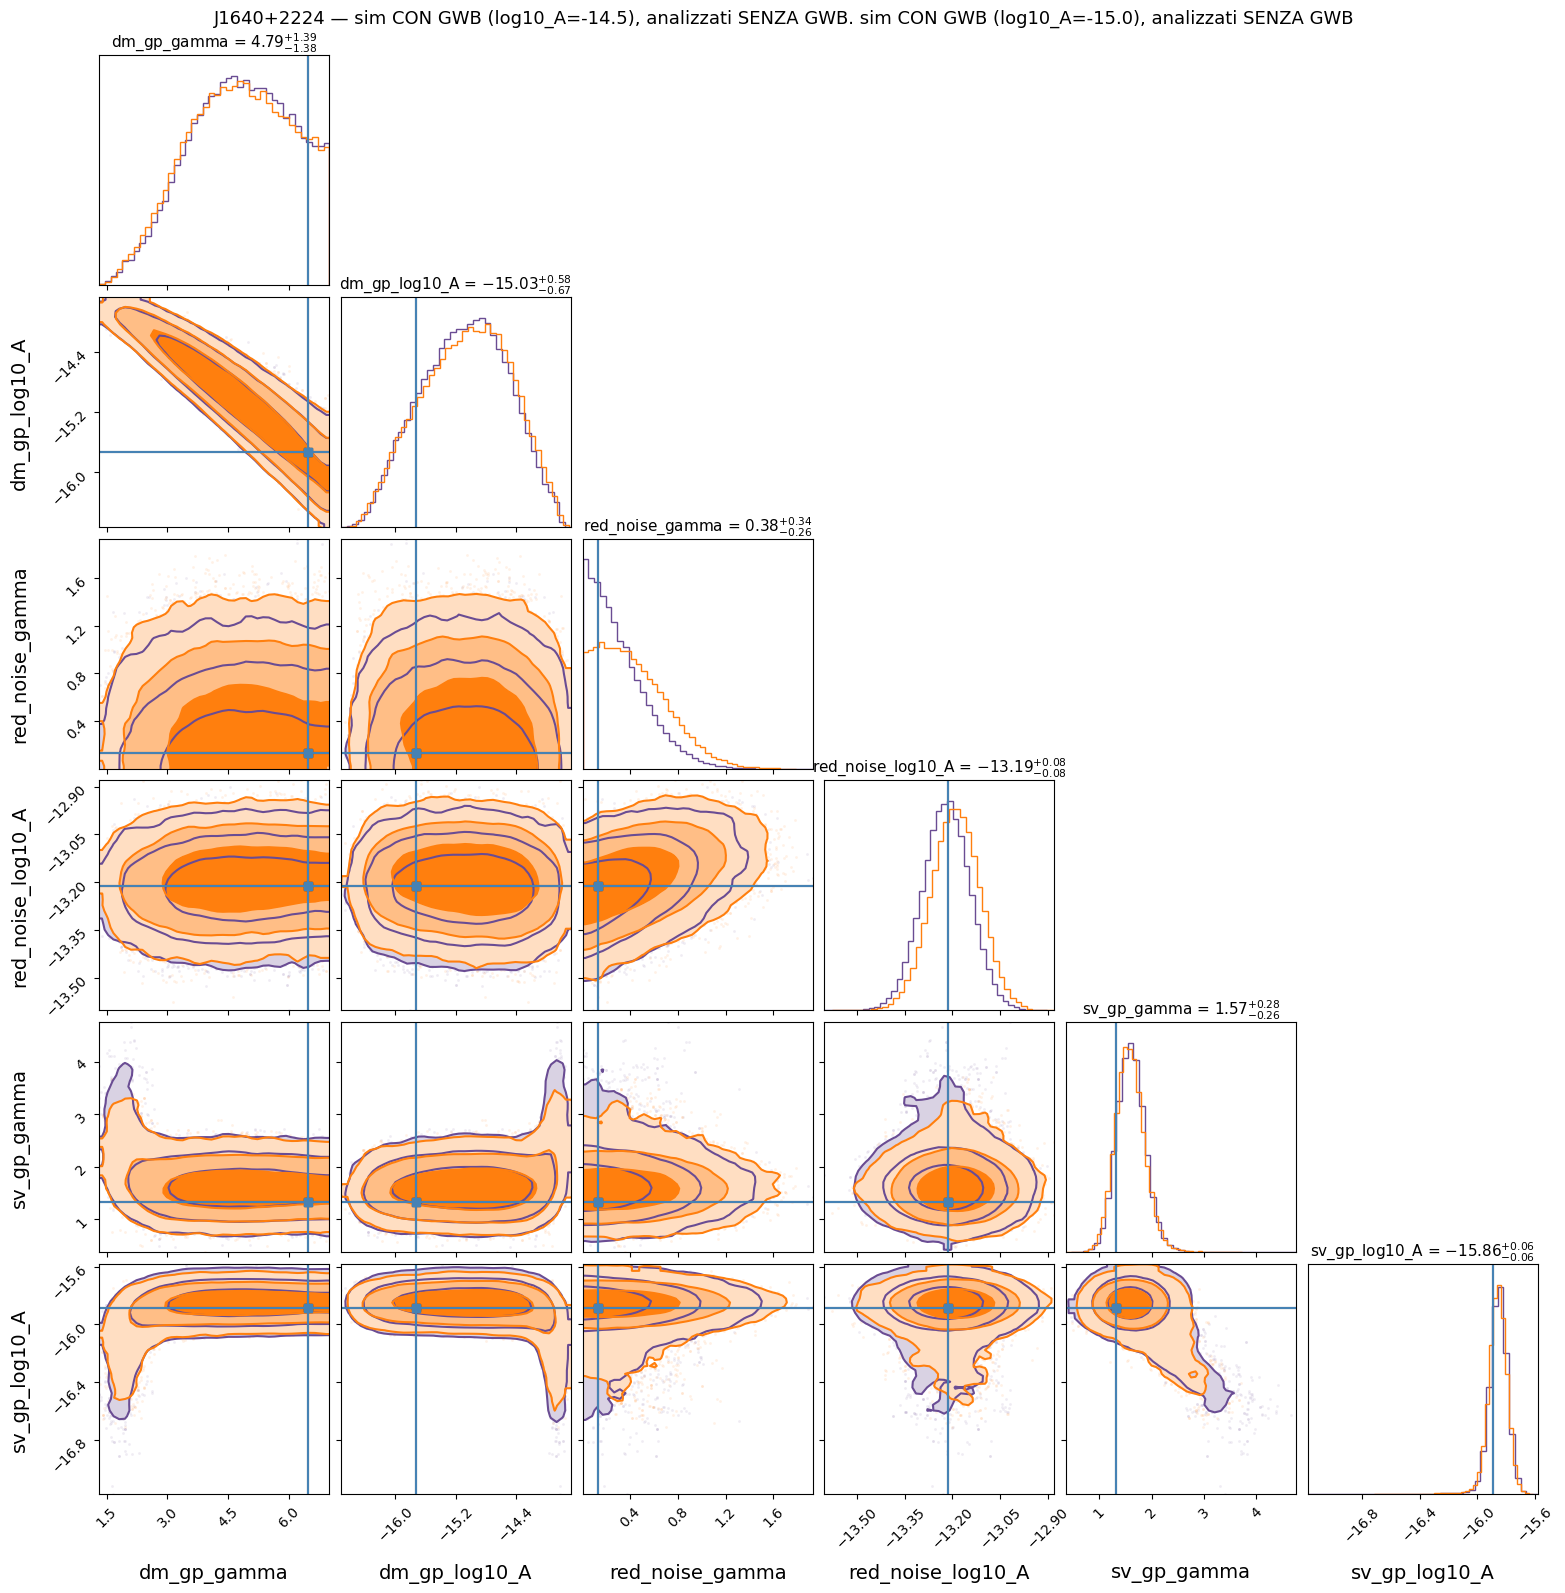

In [96]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_gwb2.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb2.params]

fig = corner.corner(
    chain_sim_gwb[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#6A4C93',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
)

corner.corner(
    chain_sim_gwb2[:],
    labels=clean_labels,
    truths=truth_values,
    #truth_color='#222221',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='tab:orange',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    fig=fig
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim CON GWB (log10_A=-14.5), analizzati SENZA GWB. sim CON GWB (log10_A=-15.0), analizzati SENZA GWB',
             fontsize=13, y=1.00)
fig.savefig('corner_sim_gwb_A145VSA150.png', dpi=150, bbox_inches='tight')

In [105]:
sim_gwb3_psr = ds.pulsar.Pulsar.read_feather('sim_data_noiseGWB_A155/J1640+2224')
print('nome     :', sim_gwb3_psr.name)
print('N_TOA    :', len(sim_gwb3_psr.toas))
print('shape M  :', sim_gwb3_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [106]:
# analizzo i dati con GWB (A=-15.5) usando lo stesso modello a 6 par dei dati reali
model_sim_gwb3 = [sim_gwb3_psr.residuals]
model_sim_gwb3 += [ds.makegp_timing(sim_gwb3_psr, svd=True)]
model_sim_gwb3 += [ds.makenoise_measurement(sim_gwb3_psr, sim_gwb3_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_gwb3.append(ds.makegp_fourier(sim_gwb3_psr, ds.powerlaw, sim_gwb3_psr.noisedict[sim_gwb3_psr.name + '_red_components'],
                                        T=ds.getspan(sim_gwb3_psr), name='red_noise'))
model_sim_gwb3.append(ds.makegp_fourier(sim_gwb3_psr, ds.powerlaw, sim_gwb3_psr.noisedict[sim_gwb3_psr.name + '_dm_components'],
                                        T=ds.getspan(sim_gwb3_psr), name='dm_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_gwb3.append(ds.makegp_fourier(sim_gwb3_psr, ds.powerlaw, sim_gwb3_psr.noisedict[sim_gwb3_psr.name + '_chrom_components'],
                                        T=ds.getspan(sim_gwb3_psr), name='sv_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim_gwb3 = ds.PulsarLikelihood(model_sim_gwb3).logL
logL_sim_gwb3.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [107]:
def params_dict_from_array_sim_gwb3(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_gwb3.params, x))

priors_sim_gwb3 = build_priors(logL_sim_gwb3.params, my_priordict)

def log_prior_sim_gwb3(x):
    params = params_dict_from_array_sim_gwb3(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_gwb3:
            logp += priors_sim_gwb3[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_gwb3():
    return np.array([priors_sim_gwb3[name].rvs() for name in logL_sim_gwb3.params])

x0_sim_gwb3 = prior_draw_sim_gwb3()

In [108]:
@jax.jit
def _jit_logL_sim_gwb3(params_array):
    return logL_sim_gwb3(dict(zip(logL_sim_gwb3.params, params_array)))

def log_likelihood_sim_gwb3(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_gwb3(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_gwb3(x0_sim_gwb3))

logL iniziale = 67946.41644965063


In [109]:
sampler_sim_gwb3 = ptmcmc(
    ndim=len(logL_sim_gwb3.params),
    logl=log_likelihood_sim_gwb3,
    logp=log_prior_sim_gwb3,
    cov=np.eye(len(logL_sim_gwb3.params)) * 0.001,
    outDir='./test_sim_gwb_A155/',
    resume=True
)

In [110]:
print("Starting sampling (dati simulati CON GWB log10_A=-15.5, analizzati SENZA GWB)...")
sampler_sim_gwb3.sample(x0_sim_gwb3, Niter=1000000, thin=10)

Starting sampling (dati simulati CON GWB log10_A=-15.5, analizzati SENZA GWB)...
Finished 1.00 percent (1.00 percent of new work) in 13.751409 s Acceptance rate = 0.2632Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 2108.500647 s Acceptance rate = 0.315505
Run Complete


In [23]:
chain_sim_gwb3 = np.loadtxt('./test_sim_gwb_A155/chain_1.txt')[:, :-4]
chain_sim_gwb3 = chain_sim_gwb3[len(chain_sim_gwb3)//4:]
chain_sim_gwb3.shape

(75001, 6)

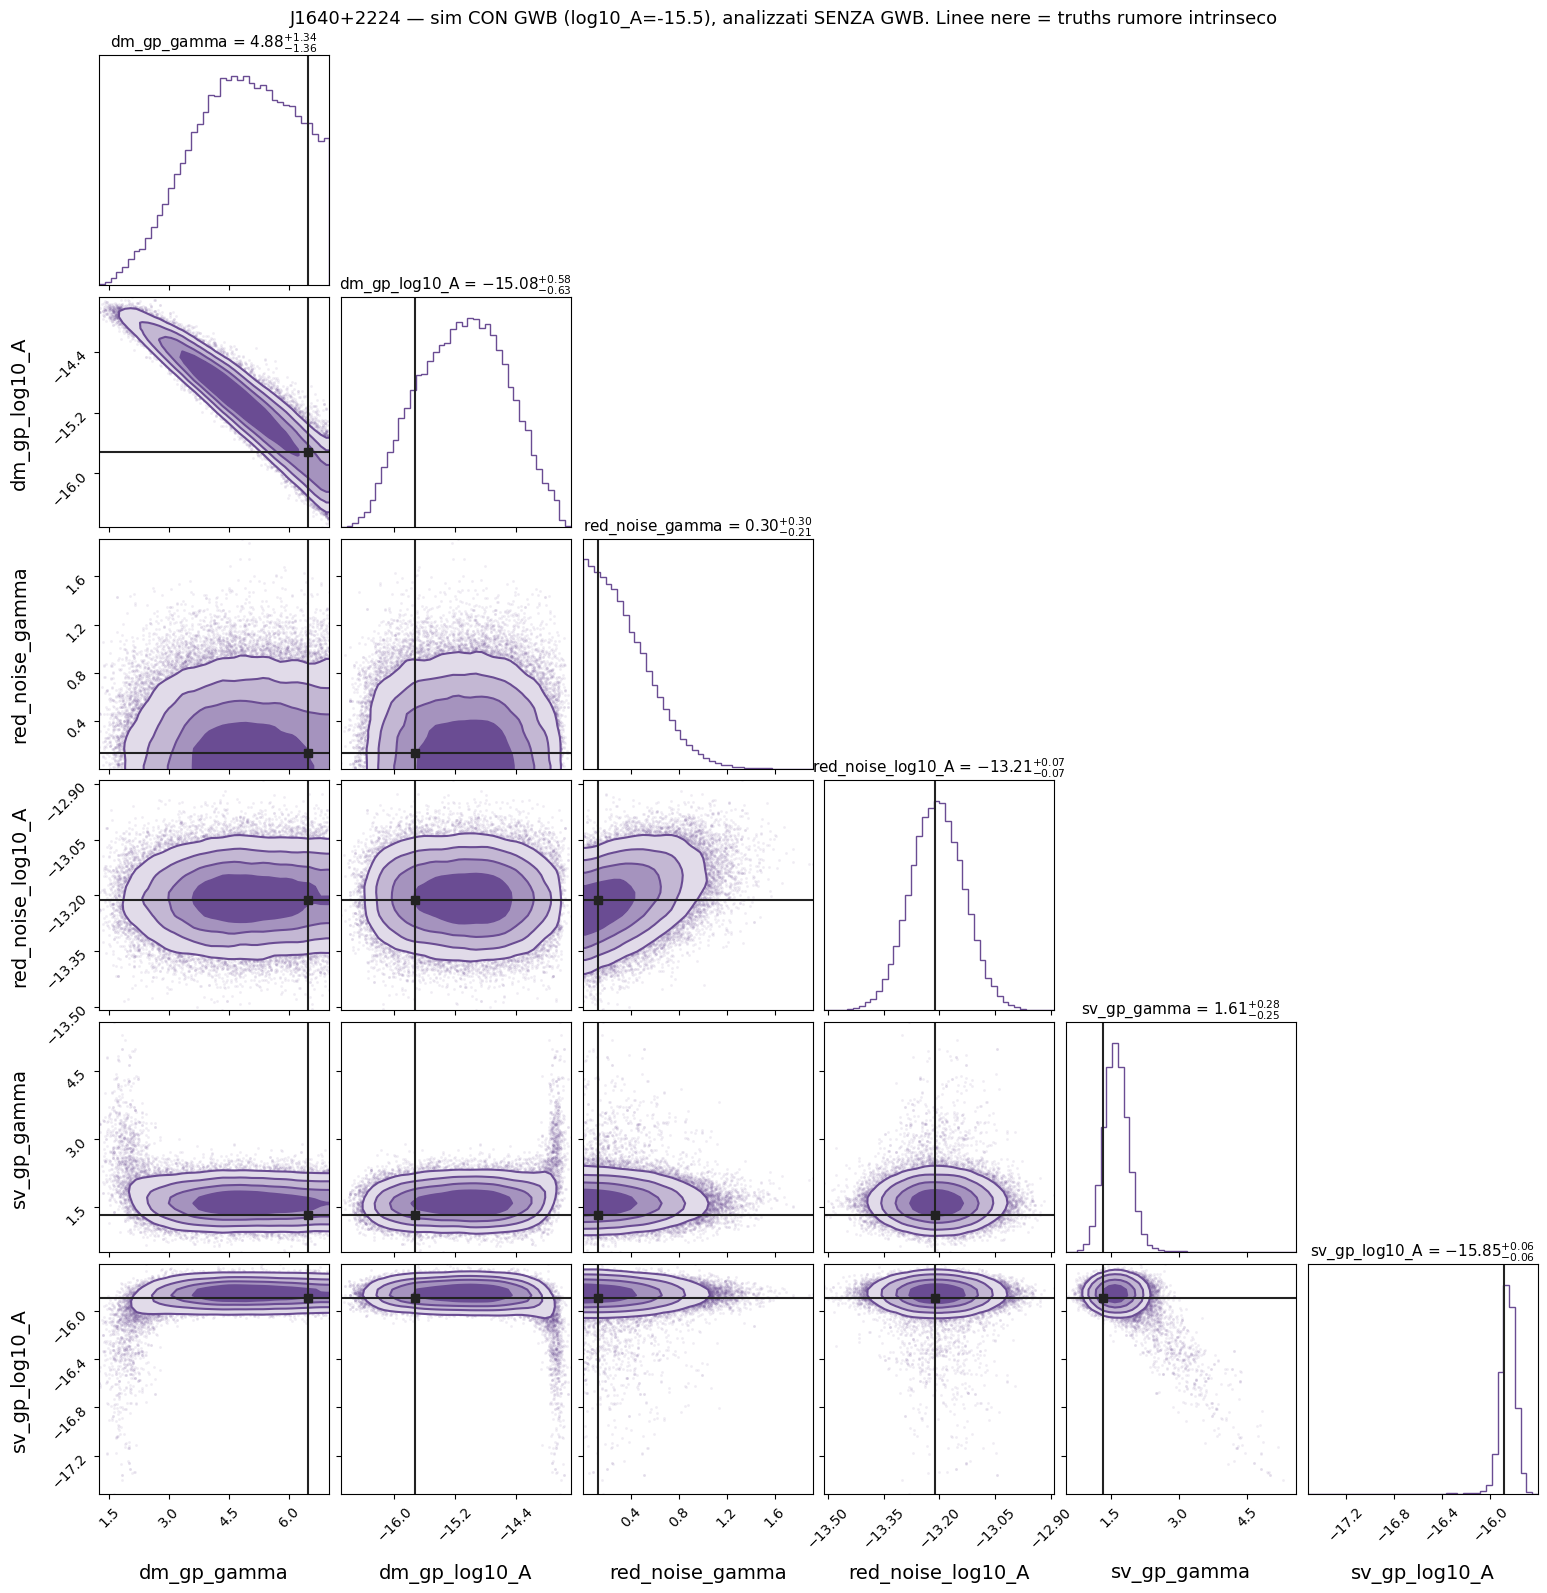

In [131]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_gwb3.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb3.params]

fig = corner.corner(
    chain_sim_gwb3[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#6A4C93',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim CON GWB (log10_A=-15.5), analizzati SENZA GWB. Linee nere = truths rumore intrinseco',
             fontsize=13, y=1.00)
fig.savefig('corner_sim_gwb_A155.png', dpi=150, bbox_inches='tight')

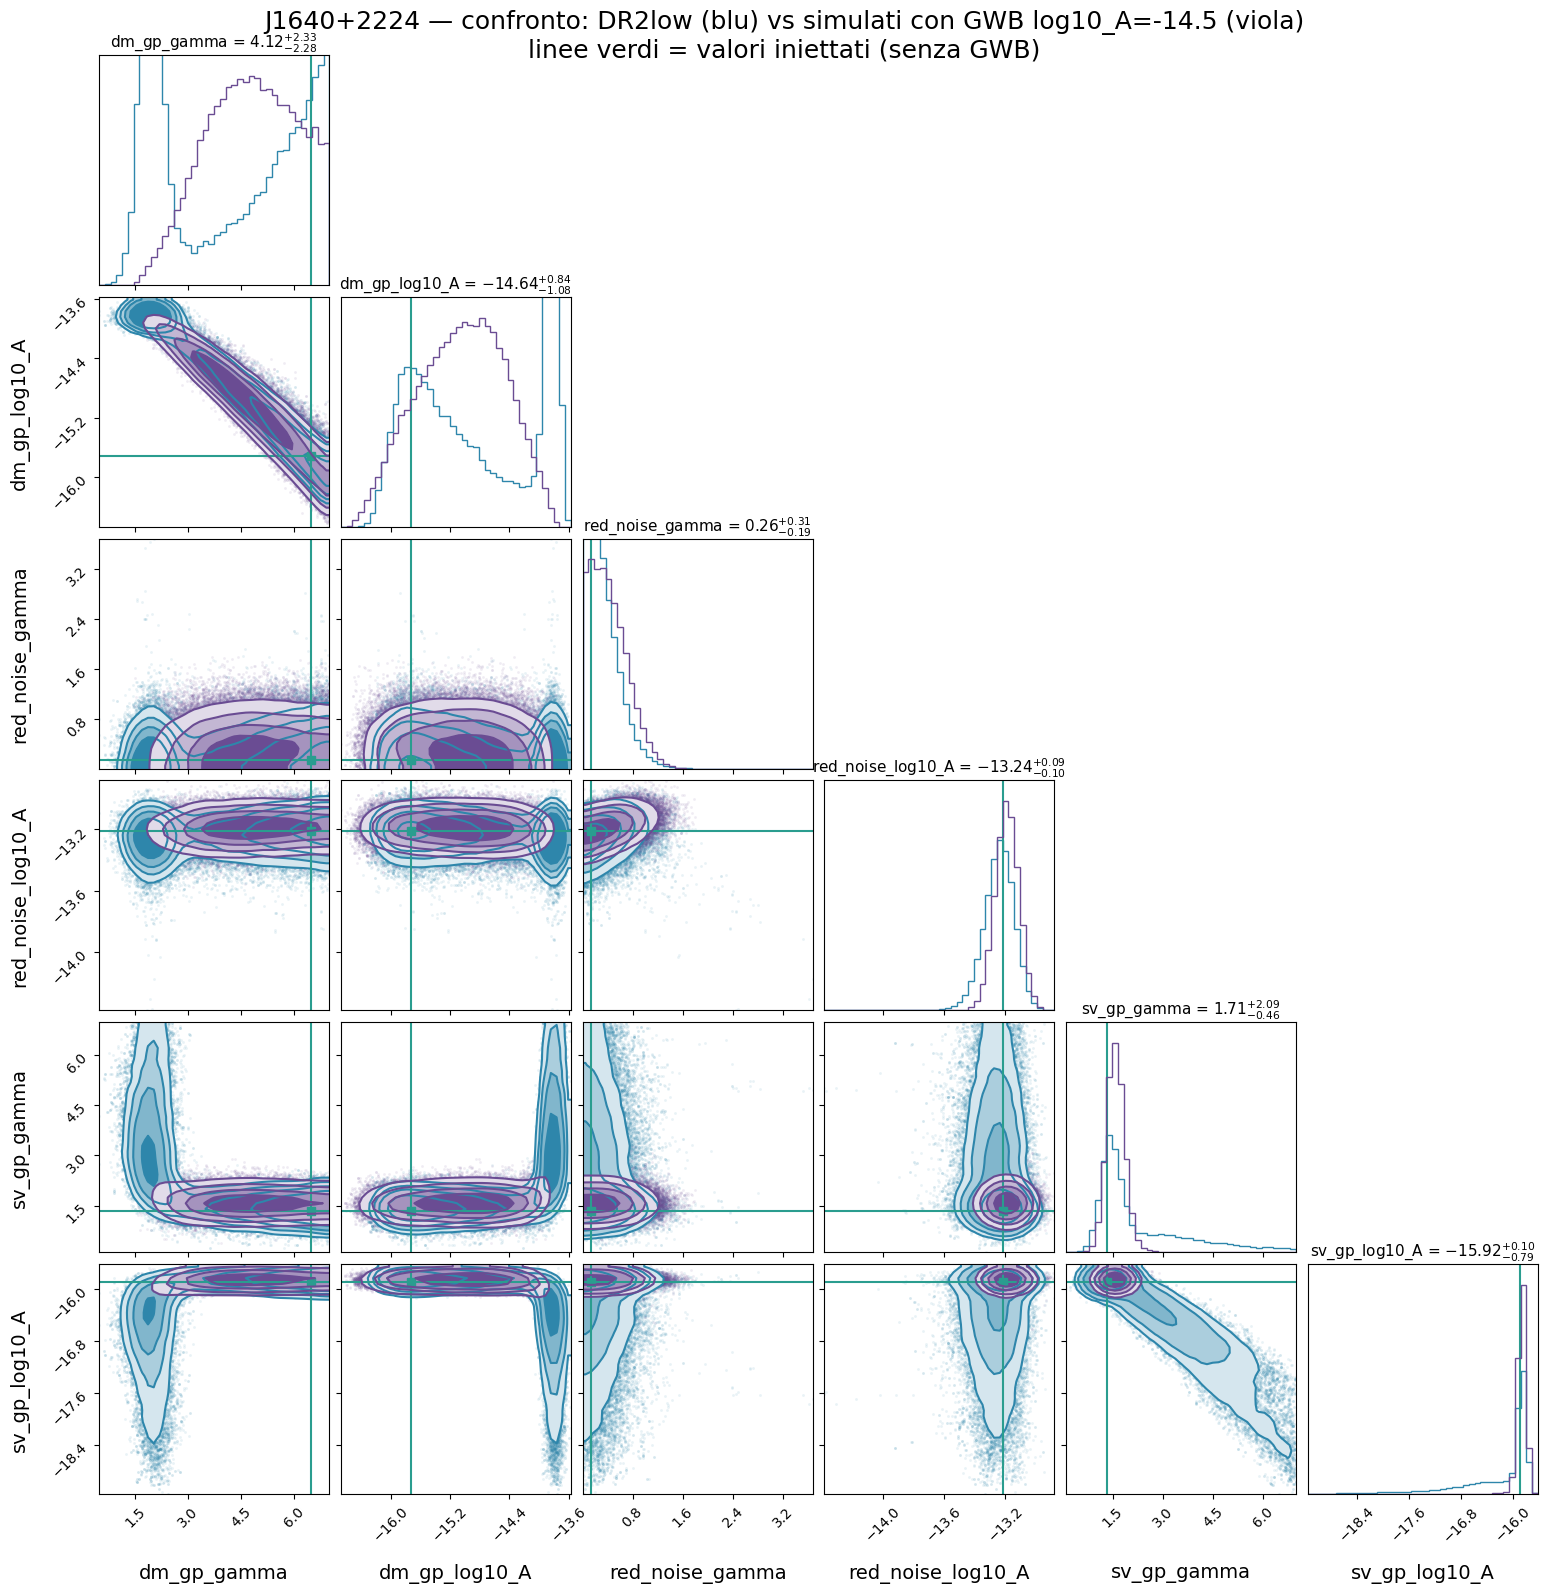

In [149]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# valori veri iniettati, nell'ordine dei parametri
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain[:], chain_sim_gwb2[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Dati REALI in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Dati SIMULATI con GWB (log10_A = -14.5) in viola, sovrapposti
corner.corner(
    chain_sim_gwb2[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: DR2low (blu) vs simulati con GWB log10_A=-14.5 (viola)\nlinee verdi = valori iniettati (senza GWB)',
             fontsize=18, y=1.00)
fig.savefig('corner_reali_vs_simGWB_A145.png', dpi=150, bbox_inches='tight')

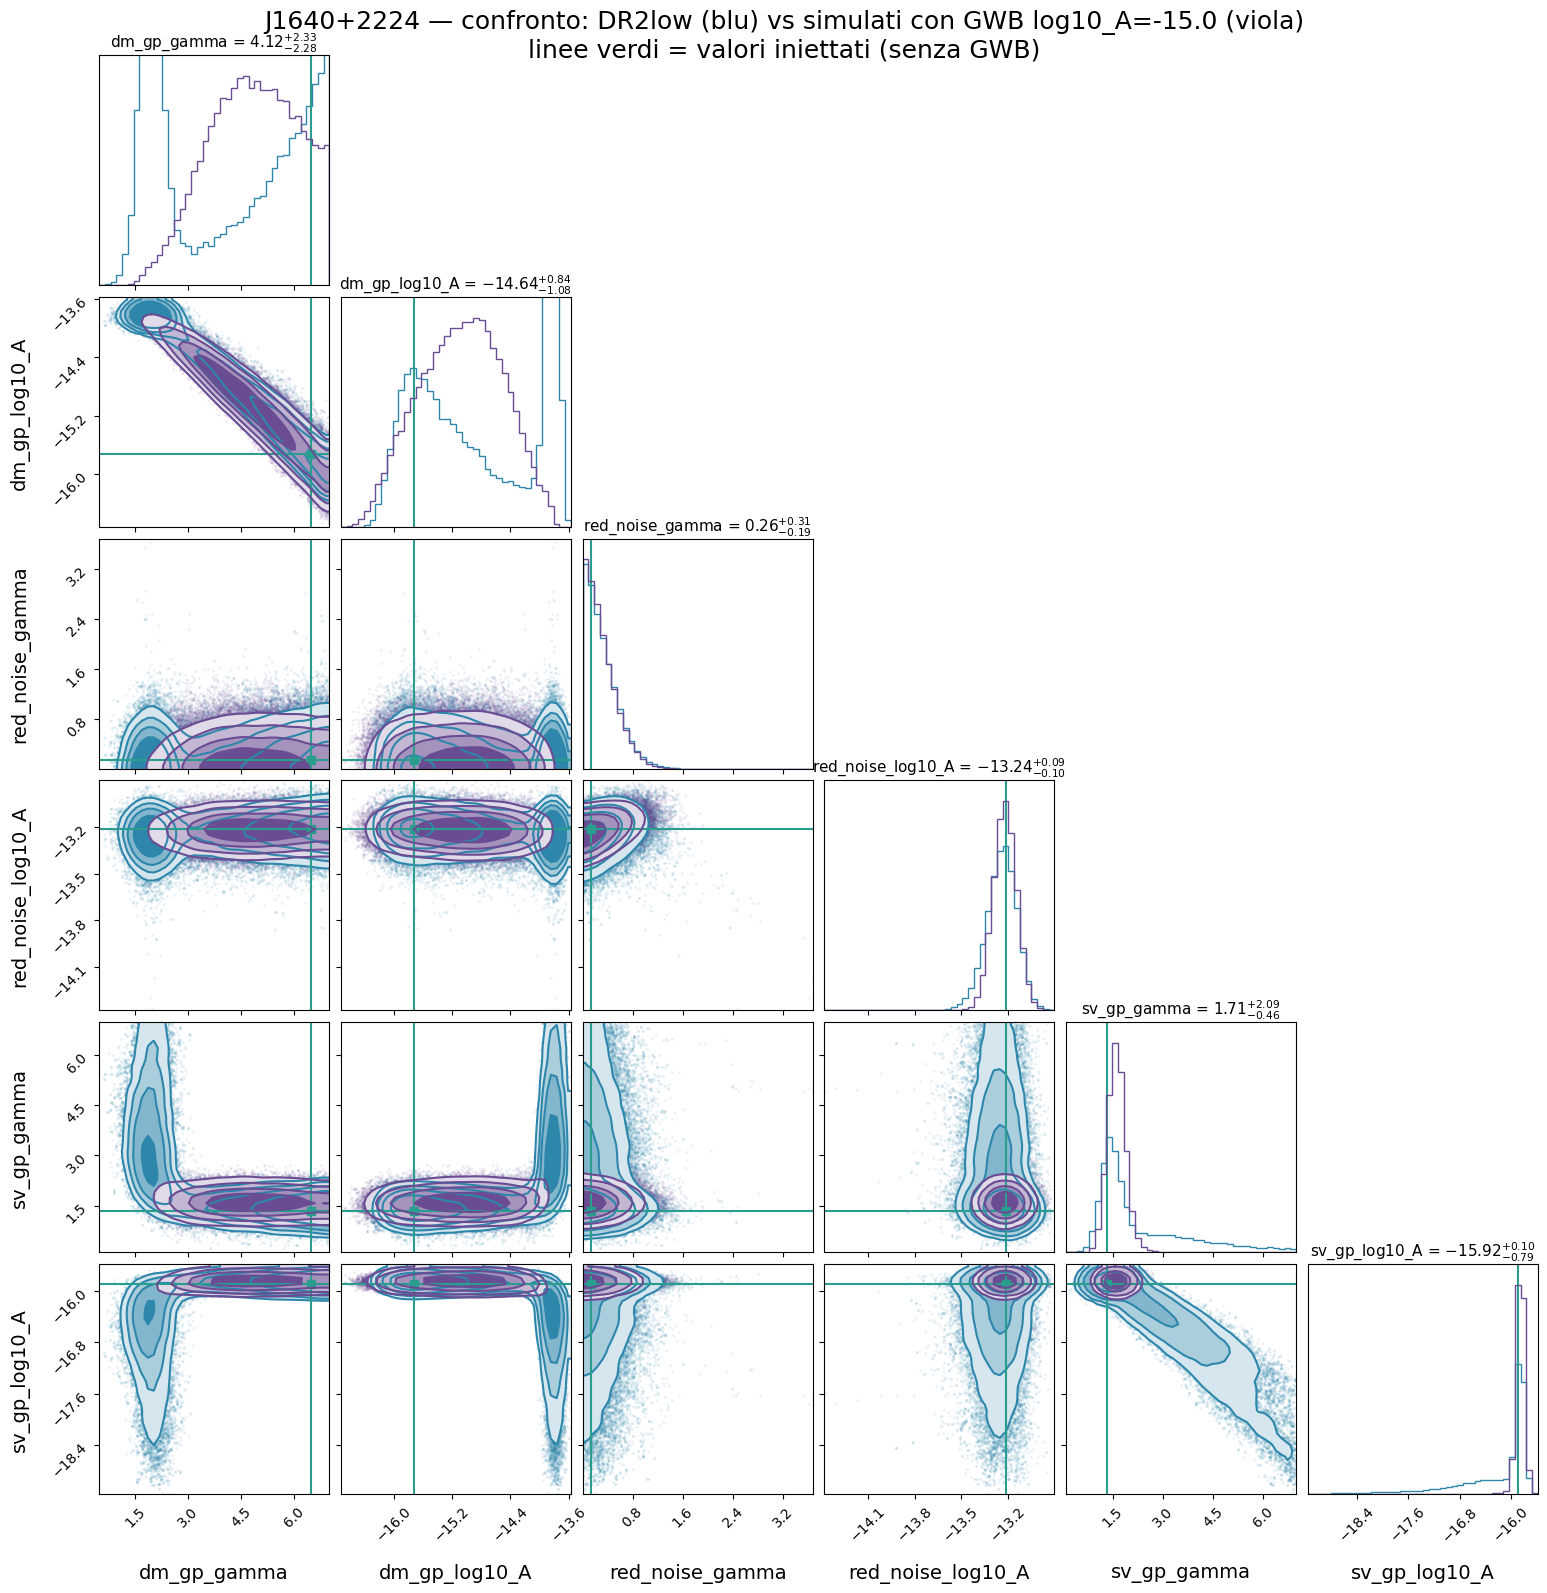

In [150]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# valori veri iniettati, nell'ordine dei parametri
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain[:], chain_sim_gwb[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Dati REALI in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Dati SIMULATI con GWB (log10_A = -15.0) in viola, sovrapposti
corner.corner(
    chain_sim_gwb[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: DR2low (blu) vs simulati con GWB log10_A=-15.0 (viola)\nlinee verdi = valori iniettati (senza GWB)',
             fontsize=18, y=1.00)
fig.savefig('corner_reali_vs_simGWB_A150.png', dpi=150, bbox_inches='tight')

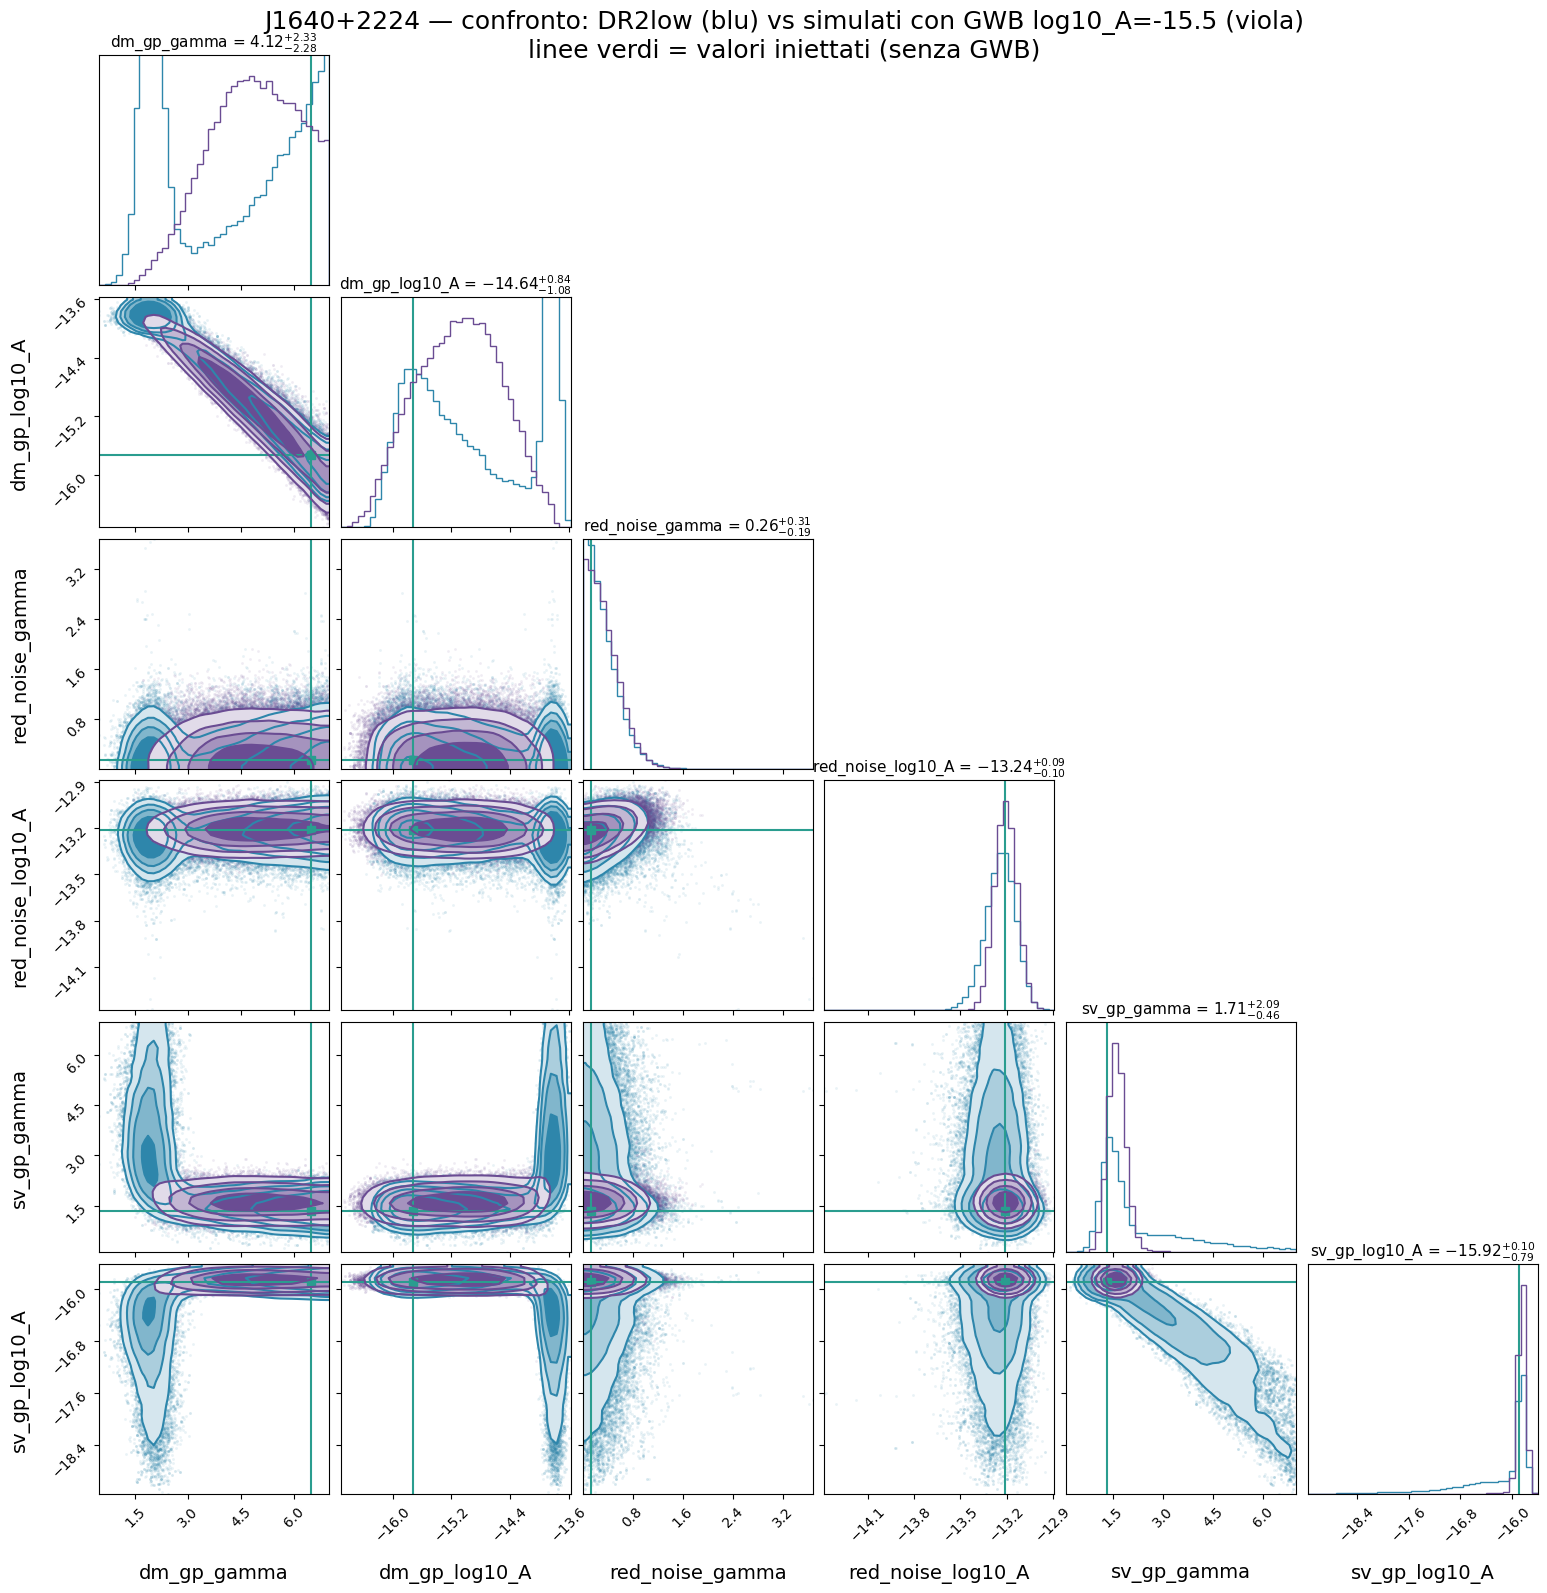

In [151]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# valori veri iniettati, nell'ordine dei parametri
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain[:], chain_sim_gwb3[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Dati REALI in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Dati SIMULATI con GWB (log10_A = -15.5) in viola, sovrapposti
corner.corner(
    chain_sim_gwb3[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: DR2low (blu) vs simulati con GWB log10_A=-15.5 (viola)\nlinee verdi = valori iniettati (senza GWB)',
             fontsize=18, y=1.00)
fig.savefig('corner_reali_vs_simGWB_A155.png', dpi=150, bbox_inches='tight')

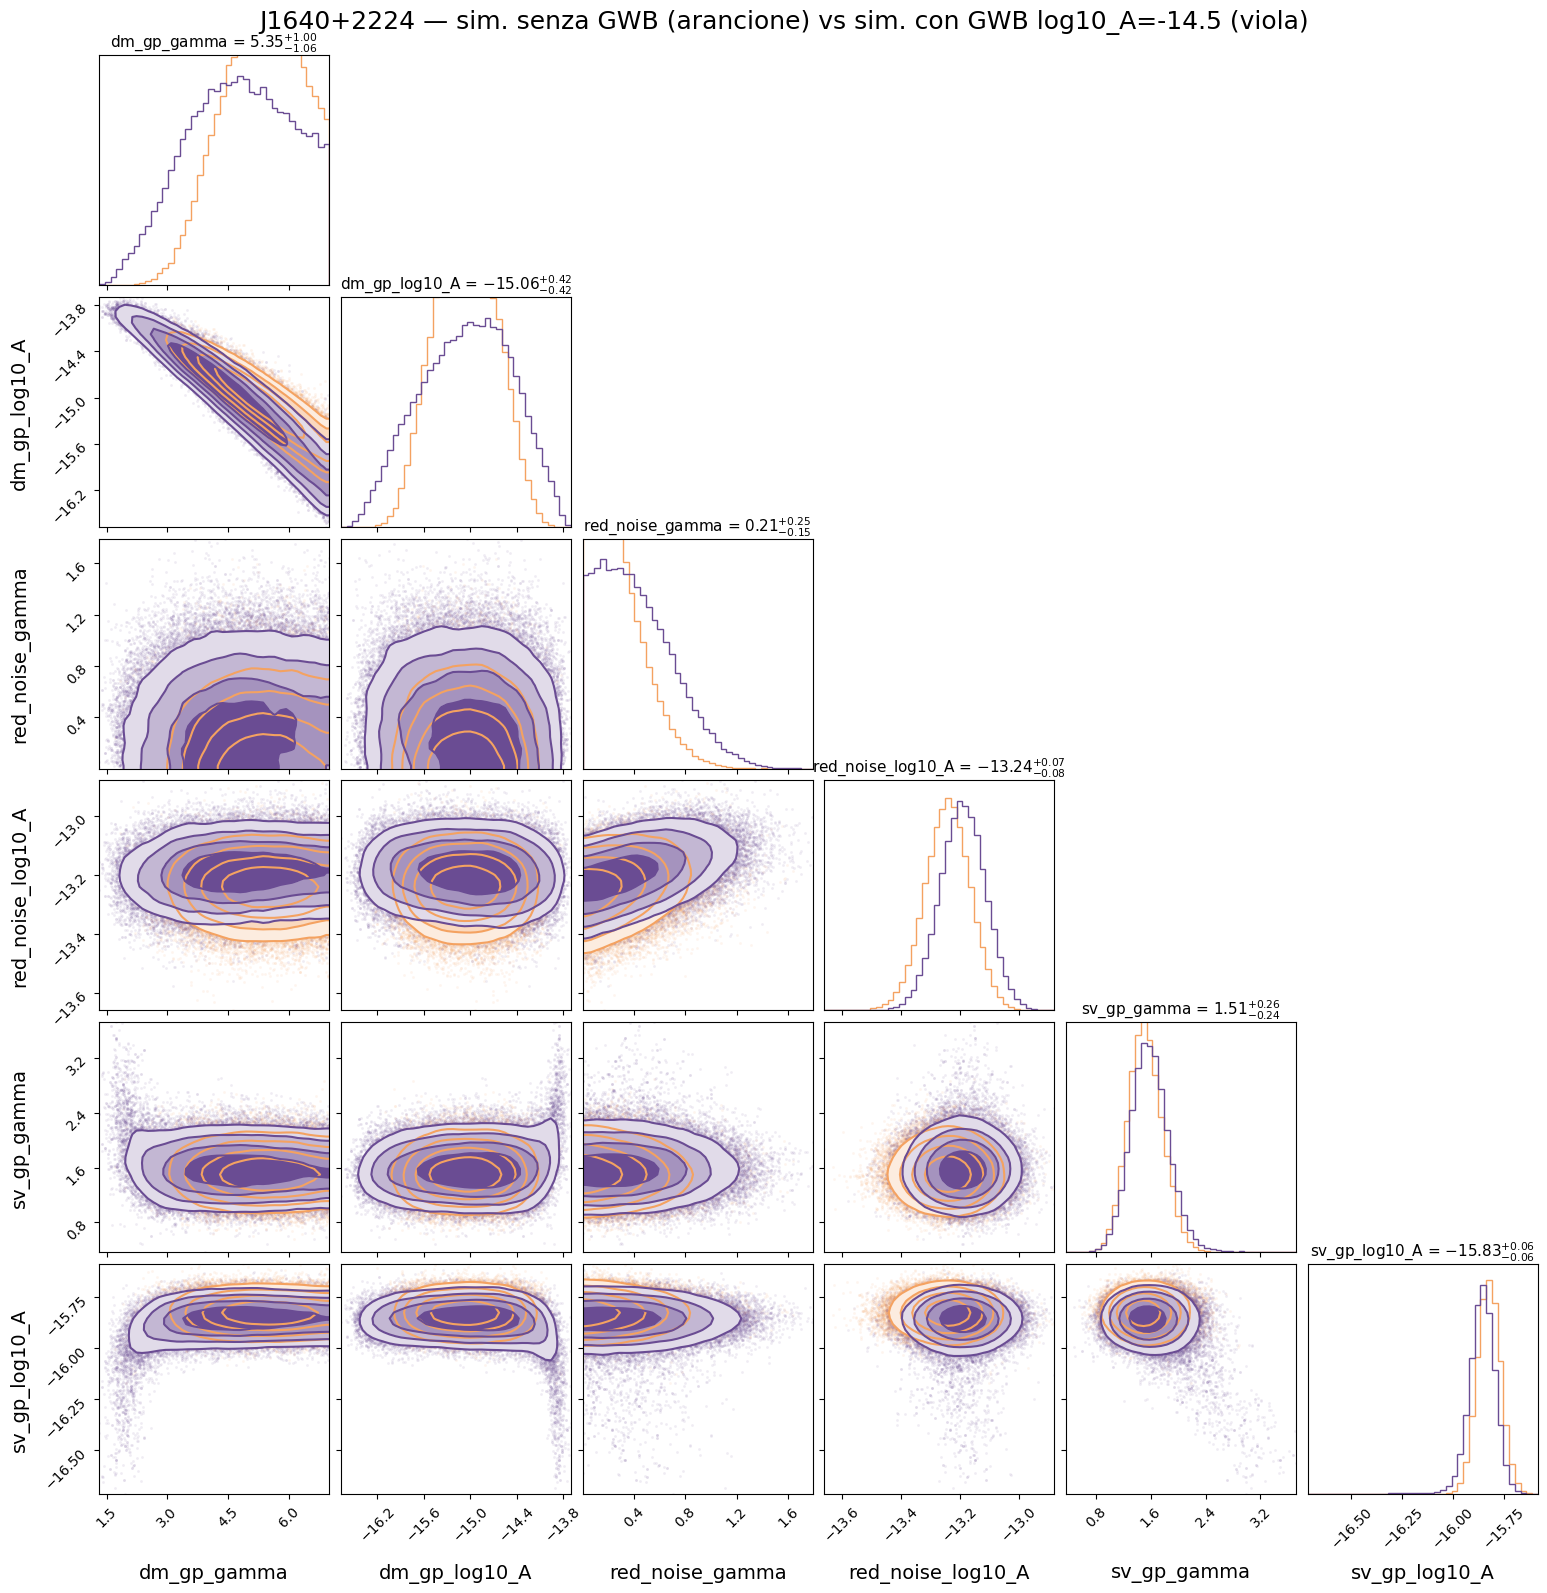

In [20]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain_sim2[:], chain_sim_gwb2[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Simulazione SENZA GWB — arancione chiaro
fig = corner.corner(
    chain_sim2[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Simulazione CON GWB (log10_A=-14.5) — viola, sovrapposta
corner.corner(
    chain_sim_gwb2[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim. senza GWB (arancione) vs sim. con GWB log10_A=-14.5 (viola)',
             fontsize=18, y=1.00)
fig.savefig('corner_sim_confronto_gwb_no_gwb.png', dpi=150, bbox_inches='tight')

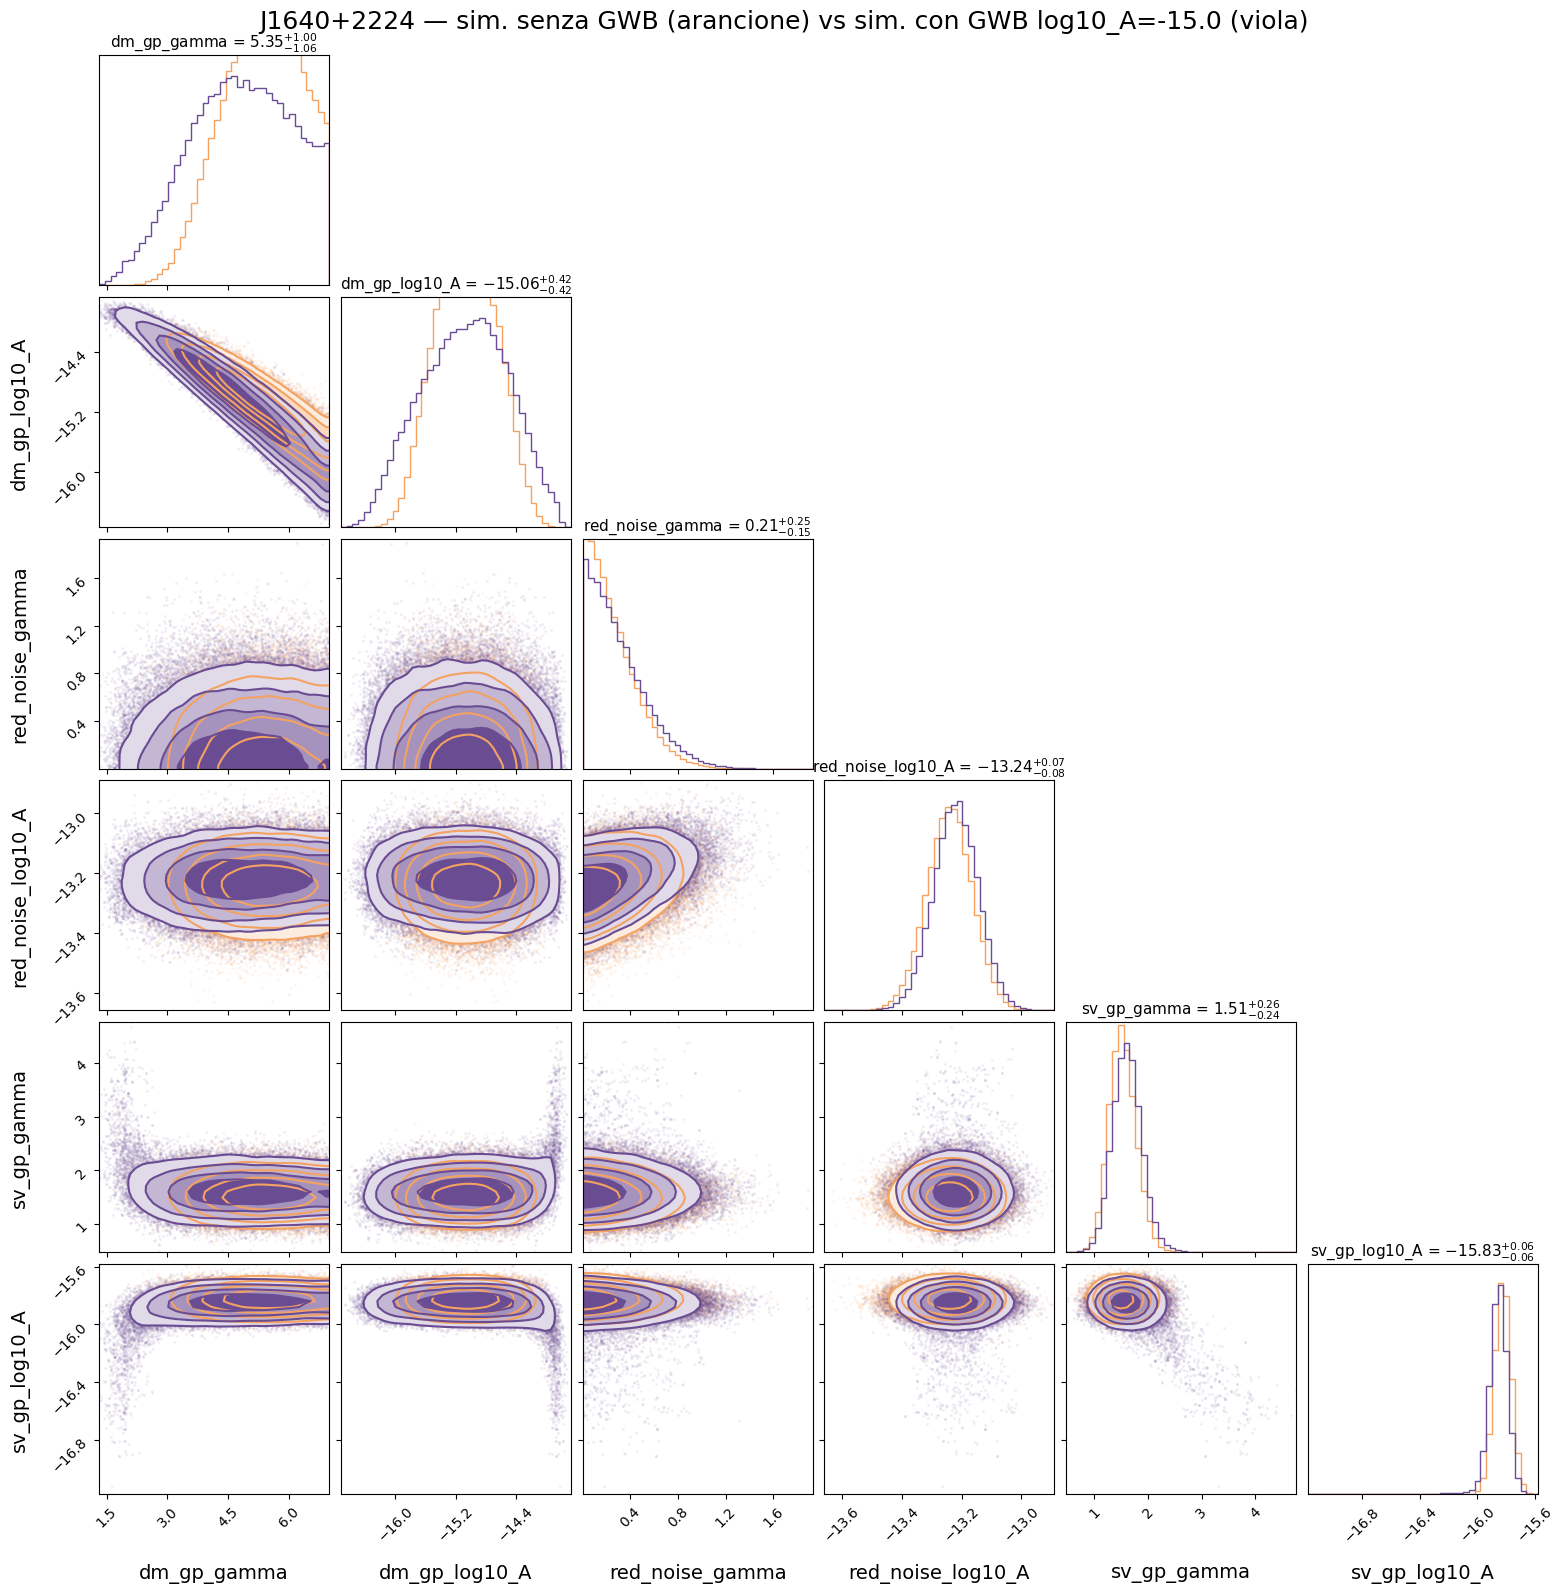

In [21]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain_sim2[:], chain_sim_gwb[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Simulazione SENZA GWB — arancione chiaro
fig = corner.corner(
    chain_sim2[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Simulazione CON GWB (log10_A=-15.0) — viola, sovrapposta
corner.corner(
    chain_sim_gwb[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim. senza GWB (arancione) vs sim. con GWB log10_A=-15.0 (viola)',
             fontsize=18, y=1.00)
fig.savefig('corner_sim_confronto_gwb_A150_no_gwb.png', dpi=150, bbox_inches='tight')

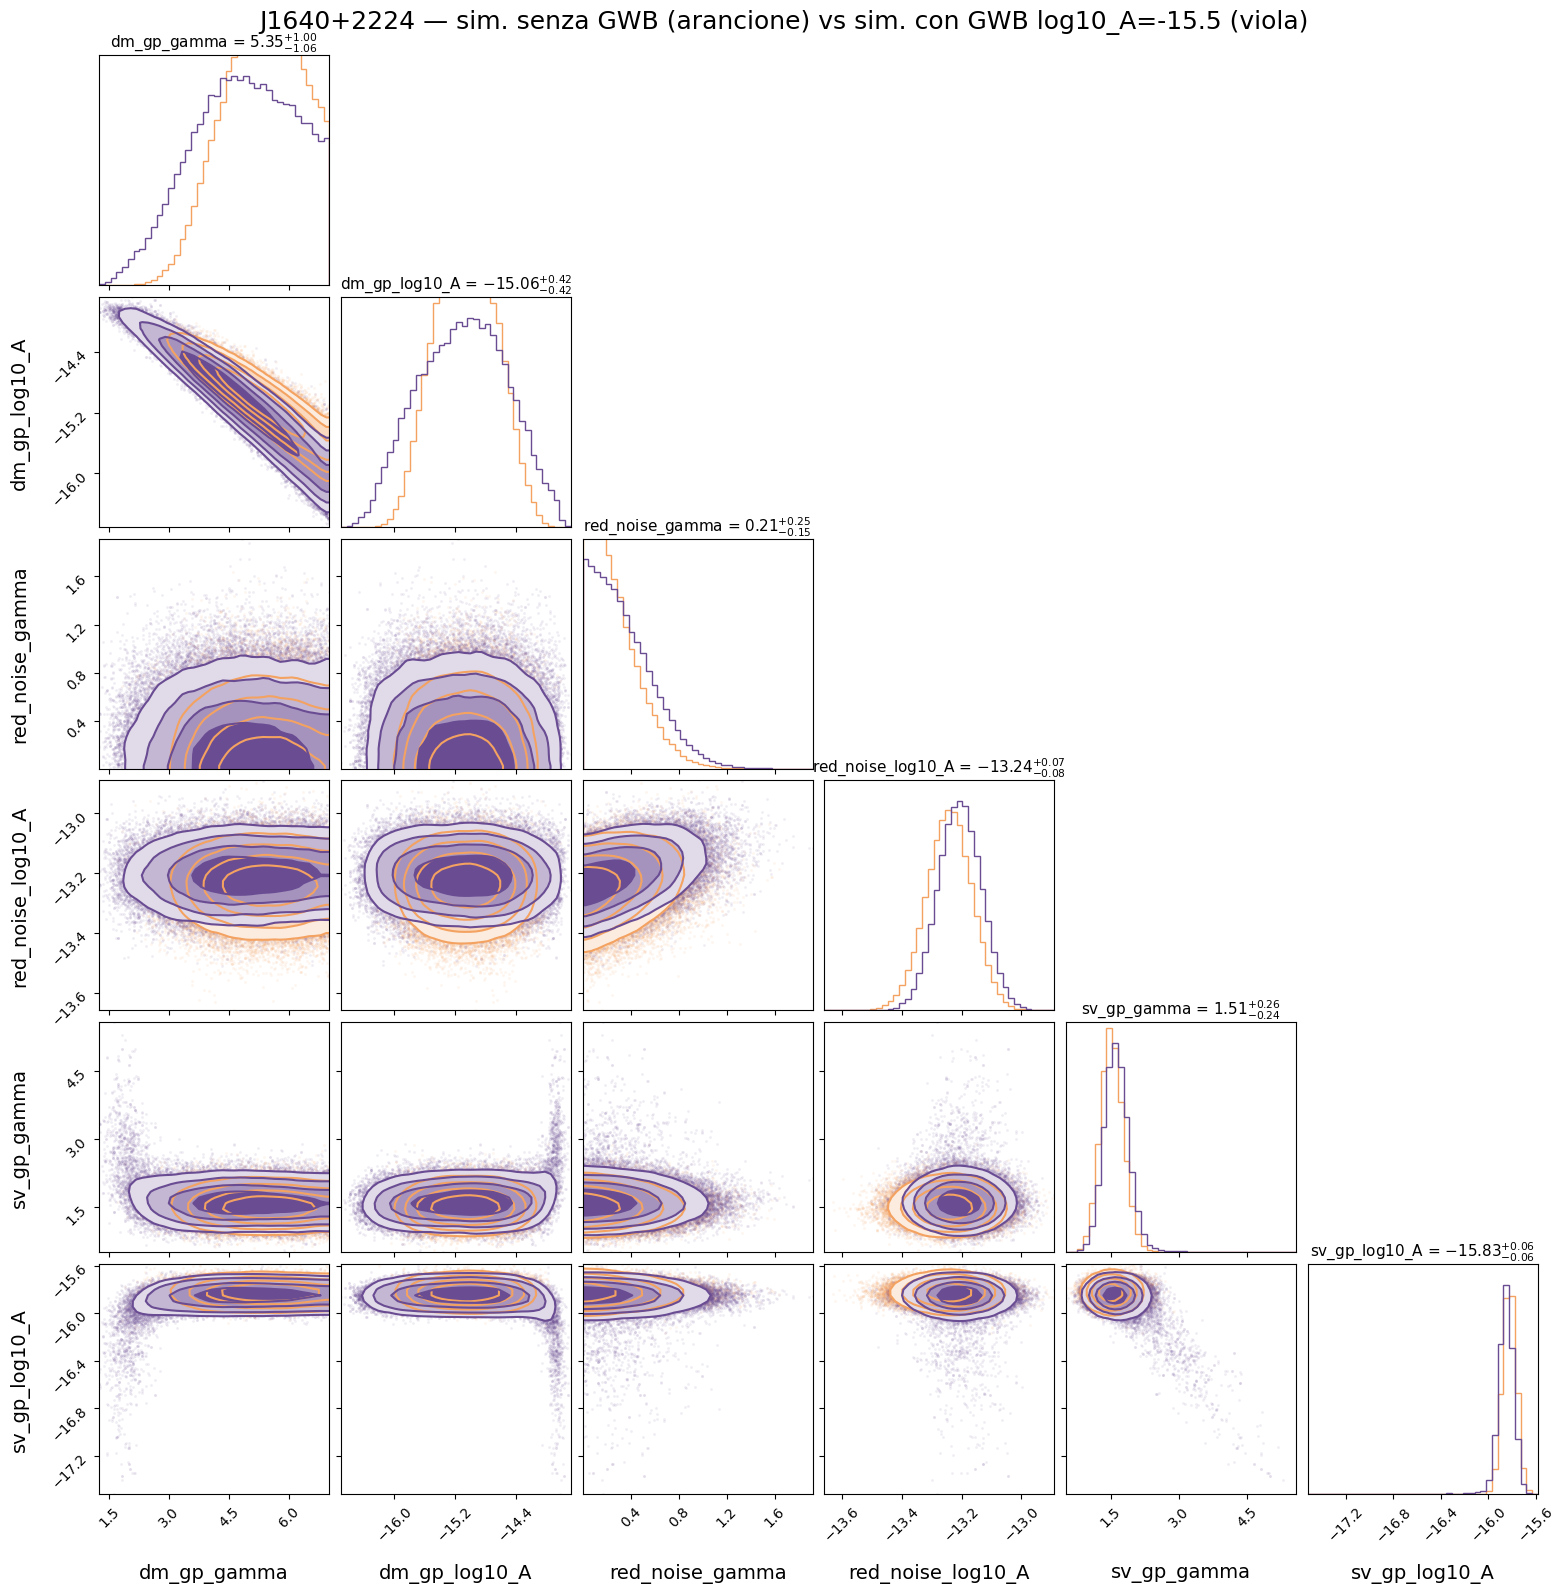

In [24]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain_sim2[:], chain_sim_gwb3[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Simulazione SENZA GWB — arancione chiaro
fig = corner.corner(
    chain_sim2[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Simulazione CON GWB (log10_A=-15.5) — viola, sovrapposta
corner.corner(
    chain_sim_gwb3[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim. senza GWB (arancione) vs sim. con GWB log10_A=-15.5 (viola)',
             fontsize=18, y=1.00)
fig.savefig('corner_sim_confronto_gwb_A155_no_gwb.png', dpi=150, bbox_inches='tight')